In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

D:\claude_project\claude_study\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    state['final'] = f"Hello {state['name']}!"
    return state

In [4]:
def second_node(state: AgentState) -> AgentState:
    state['final'] = f"{state['final']} your are {state['age']} years old."
    return state

In [7]:
graph = StateGraph(AgentState)
graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.set_entry_point("first")
graph.add_edge("first", "second")
graph.set_finish_point("second")
app = graph.compile()

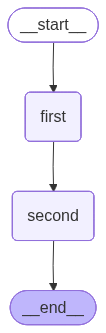

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [54]:
result = app.invoke({"name": "Dean", "age": 25})
print(result)

KeyError: 'operation'

In [56]:
result2 = app.invoke({"name": "Dean", "age": 25})
print(result2)

KeyError: 'operation'

In [8]:
class AgentState2(TypedDict):
    number1: int
    operation: str
    number2: int
    finalnumber: int
def adder(state: AgentState2) -> AgentState2:
    state['finalnumber'] = state['number1'] + state['number2']
    return state
def subtractor(state: AgentState2) -> AgentState2:
    state['finalnumber'] = state['number1'] - state['number2']
    return state
def decider_next_node(state: AgentState2) -> str:
    if state['operation'] == '+':
        return 'adder_node'
    elif state['operation'] == '-':
        return 'subtractor_node'
graph = StateGraph(AgentState2)
graph.add_node("adder",adder)
graph.add_node("subtractor",subtractor)
graph.add_node("decider", lambda state: state)
graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",
                            decider_next_node,
                            {
                               "adder_node": "adder",
                                "subtractor_node": "subtractor"
                            }
                            )
graph.add_edge("adder", END)
graph.add_edge("subtractor", END)
app = graph.compile()

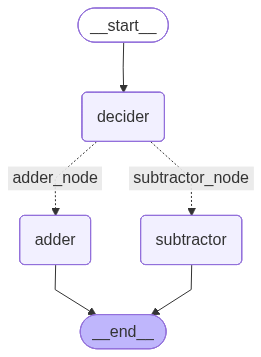

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
initial_state = {
    "number1": 10,
    "operation": "+",
    "number2": 5
}
print(app.invoke(initial_state))

{'number1': 10, 'operation': '+', 'number2': 5, 'finalnumber': 15}


In [13]:
second_state = {
    "number1": 10,
    "operation": "-",
    "number2": 5
}
print(app.invoke(second_state))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalnumber': 5}


In [14]:
class TestState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalnumber: int
    number3: int
    number4: int
    operation2: str
    finalnumber2: int

def adder(state: TestState) -> TestState:
    state['finalnumber'] = state['number1'] + state['number2']
    return state

def subtractor(state: TestState) -> TestState:
    state['finalnumber'] = state['number1'] - state['number2']
    return state

def decider_next_node(state: TestState) -> str:
    if state['operation'] == '+':
        return 'adder_node'
    elif state['operation'] == '-':
        return 'subtractor_node'

def decider_next_node2(state: TestState) -> str:
    if state['operation2'] == '+':
        return 'adder_node2'
    elif state['operation2'] == '-':
        return 'subtractor_node2'

def adder2(state: TestState) -> TestState:
    state['finalnumber2'] = state['number3'] + state['number4']
    return state

def subtractor2(state: TestState) -> TestState:
    state['finalnumber2'] = state['number3'] - state['number4']
    return state

graph3 = StateGraph(TestState)
graph3.add_node("adder",adder)
graph3.add_node("adder2",adder2)
graph3.add_node("subtractor",subtractor)
graph3.add_node("subtractor2",subtractor2)
graph3.add_node("route1", lambda state: state)
graph3.add_node("route2", lambda state: state)
graph3.add_edge(START, "route1")
graph3.add_conditional_edges("route1", decider_next_node, {"adder_node": "adder", "subtractor_node": "subtractor"})
graph3.add_edge("adder", "route2")
graph3.add_edge("subtractor", "route2")
graph3.add_conditional_edges("route2", decider_next_node2, {"adder_node2": "adder2", "subtractor_node2": "subtractor2"})
graph3.add_edge("adder2", END)
graph3.add_edge("subtractor2", END)
app3 = graph3.compile()

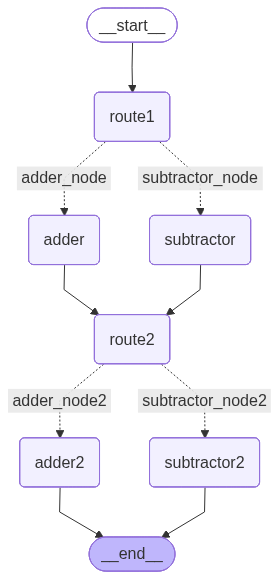

In [15]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [16]:
print(app3.invoke({"number1":10,"number2":5,"operation":"-","number3":7,"number4":2,"operation2":"+", "finalnumber":0,"finalnumber2":0}))

{'number1': 10, 'number2': 5, 'operation': '-', 'finalnumber': 5, 'number3': 7, 'number4': 2, 'operation2': '+', 'finalnumber2': 9}


In [1]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph,START,END
import random

class AgentState(TypedDict):
    name: str
    number: List[int]
    count: int

D:\claude_project\claude_study\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
def greeting_name(state: AgentState) -> AgentState:
    state["name"] = f"Hi, there {state['name']}"
    state["count"] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    state["number"].append(random.randint(0, 10))
    state["count"] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    if state["count"] < 5:
        print(f"Enter loop, {state['count']}")
        return "loop"
    else:
        return "exit"


In [3]:
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_name)
graph.add_node("random", random_node)
graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)
app = graph.compile()

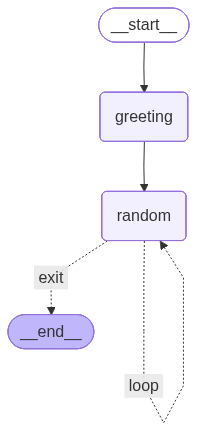

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
app.invoke({"name":"dean", "number":[], "count":0})

Enter loop, 1
Enter loop, 2
Enter loop, 3
Enter loop, 4


{'name': 'Hi, there dean', 'number': [10, 2, 7, 3, 5], 'count': 5}